# Student Depression -Machine Learning Project 

## Business Understanding

Our goal is to extract meaningful and concrete tips and advice for students to help combat depression: finding breakpoints for sleep amounts, academic pressure and studying the possible correlative effects of family mental illness history. 

A decision tree-based approach is best suited for this as each nodes' binary decision has insight on how to avoid getting depressed.

## Data Understanding

The dataset we're working with contains information about students across various Indian cities, capturing demographic information, academic factors, lifestyle habits, and mental health indicators. The target variable, Depression, is a binary classification where 1 indicates the presence of depression and 0 indicates its absence.



In [68]:
import pandas as pd

df = pd.read_csv('datasets/student_depression_dataset.csv')

df.tail(5)

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,'5-6 hours',Unhealthy,'Class 12',Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,'Less than 5 hours',Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,'5-6 hours',Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,'Less than 5 hours',Healthy,'Class 12',Yes,10.0,5.0,No,1
27900,140699,Male,27.0,Patna,Student,4.0,0.0,9.24,1.0,0.0,'Less than 5 hours',Healthy,BCA,Yes,2.0,3.0,Yes,1


In [69]:
print(f'Amount of rows in the dataset: {df.shape[0]}')

Amount of rows in the dataset: 27901


In [70]:
vc = df['Depression'].value_counts(normalize=True)
incidence = vc.get(1, 0) * 100
print(f"Incidence of depression within dataset: {incidence:.2f}%")
df['Depression'].value_counts(normalize=True)

Incidence of depression within dataset: 58.55%


Depression
1    0.585499
0    0.414501
Name: proportion, dtype: float64

The amount of depressed students in the data seems to be higher than publicly available research would imply even though the dataset is large. Either the survey participant group is biased, or the dataset is not based on real data.

Next we check dataset for missing values:

In [71]:
missing_values = df.isnull().sum()
print(missing_values)

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64


## Data Preparation

In [72]:
df = pd.get_dummies(df)

## Modeling

In [73]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree  

X = df.drop(['Depression'], axis = 1) # input features
y = df['Depression'].astype('category') # target features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=20) # extract test set
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(20925, 123) (6976, 123) (20925,) (6976,)


In [81]:
model = DecisionTreeClassifier(max_depth=3, random_state=20)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=20)

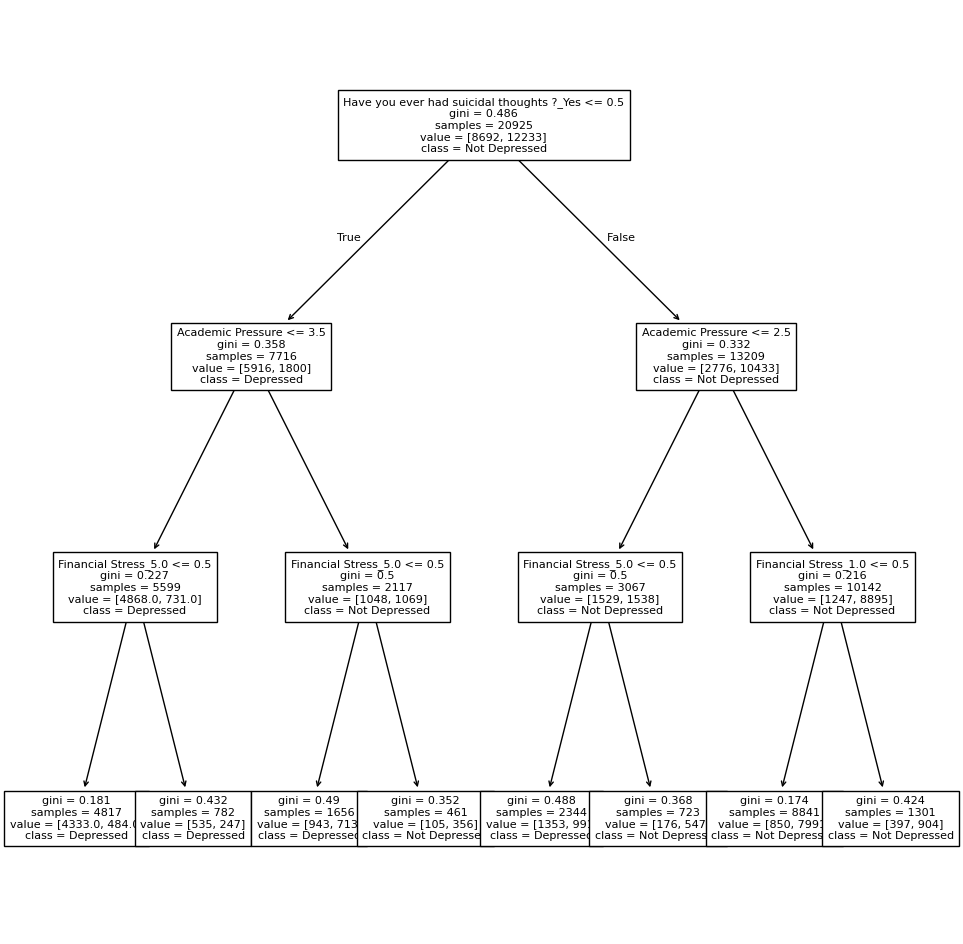

In [86]:
fig = plt.figure(figsize = (12, 12))
plot_tree(model, feature_names = X.keys(), class_names = ['Depressed', 'Not Depressed'], fontsize=8)
plt.show()

## Evaluation and Validation

## Deployment